In [1]:
import os
import torch
import torch.nn as nn
from Dataload.dataload import InpaintingData
from model.model import InpaintGenerator, Discriminator
from attrdict import AttrDict
from glob import glob
from loss.loss import Perceptual,L1,Style,smgan
import json
# 启用梯度异常检测
torch.autograd.set_detect_anomaly(True)

#定义训练参数
batch_size = 1

num_epochs = 137 #已经训练了136个周期，这里训练一次作为演示，代表代码能正常运行
lr = 0.00005
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 初始化数据加载参数
args = {
    "dir_image": "./datasets/train/face",
    "data_train": "celeb",
    "dir_mask": "./datasets/train/face-mask",
    "mask_type": "pconv",
    "image_size": 512,
}
args = AttrDict(args)
# 初始化损失累加器
avg_losses = {
    "L1": 0,
    "Style": 0,
    "Perceptual": 0,
    "advg": 0,
    "advd": 0
}
#定义模型
model_generator = InpaintGenerator().to(device)
model_discriminator = Discriminator().to(device)


# 定义优化器
optimizer_G = torch.optim.Adam(model_generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(model_discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

#定义损失函数
l1,perceptual,style,Smgan = L1(),Perceptual(),Style(),smgan()
# 检查是否存在检查点，尝试读取最新检查点
checkpoint_dir = './training_checkpoints/'
if os.path.exists(checkpoint_dir):
    checkpoints = glob(os.path.join(checkpoint_dir,"*.pth"))
    if checkpoints:
        latest_checkpoint = max(checkpoints, key=os.path.getctime)
        checkpoint = torch.load(latest_checkpoint)
        model_generator.load_state_dict(checkpoint['generator_state_dict'])
        model_discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
        optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
        optimizer_D.load_state_dict(checkpoint['optimizer_D_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Loaded checkpoint '{latest_checkpoint}' (epoch {start_epoch})")
    else:
        start_epoch = 0
        print("No checkpoints found, starting training from scratch")
else:
    os.makedirs(checkpoint_dir, exist_ok=True)
    start_epoch = 0
    print("Checkpoint directory not found, starting training from scratch")

# 训练循环
for epoch in range(start_epoch, num_epochs):
    total_iter = 0
    data = InpaintingData(args)
    batch_num = len(data)//batch_size+1
    for batch_idx in range(batch_num):
        datalist,labellist,masklist = [],[],[]
        for iter in range(batch_size):
            image ,mask, filename = data[total_iter]
            total_iter += 1
            # 将数据移到设备上
            image = image.to(device)
            mask = mask.to(device)
            masked_image = (image * (1 - mask).float()) + mask  #生成带掩码的人脸图
            masked_img = torch.cat((masked_image, mask), dim=0)  #将掩码图与带掩码的人脸图在通道上进行拼接 变为3+1=4通道
            datalist.append(masked_img.unsqueeze(0))
            labellist.append(image.unsqueeze(0))
            masklist.append(mask.unsqueeze(0))
        if total_iter >= len(data)-1:
            break
        input = torch.cat(datalist, dim=0)
        realimage = torch.cat(labellist, dim=0)
        mask = torch.cat(masklist,dim=0)
        

        # 生成修复图像 in: [rgb(3)+edge(1)]
        pred_img = model_generator(input)
        comp_img = (1 - mask) * realimage + mask * pred_img
        # reconstruction losses
        losses = {}
        for loss_func, weight in ((l1,1),(style,100),(perceptual,0.1)):
            losses[loss_func.__class__.__name__] = weight * loss_func(pred_img, realimage)
    

         # adversarial loss
        dis_loss, gen_loss = Smgan(model_discriminator, comp_img, realimage, mask)
        losses["advg"] = gen_loss * 0.01  #adv weight
        # 反向传播和优化
        optimizer_D.zero_grad()
        optimizer_G.zero_grad()
        sum(losses.values()).backward()
        losses["advd"] = dis_loss
        dis_loss.backward()
        optimizer_D.step()
        optimizer_G.step()

        
        

        # 打印损失信息
        if (batch_idx+1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx+1}/{len(data)}], "
                f"Gl1_Loss: {losses["L1"]:.4f}, GStyle_Loss: {losses["Style"]:.4f},GPerceptual_Loss: {losses["Perceptual"]:.4f},Gadv_Loss: {losses["advg"]:.4f},Discriminator Loss: {losses["advd"]:.4f}")
        # 累加损失
        for key in avg_losses:
            avg_losses[key] += losses[key].item()
    # 计算平均损失
    for key in avg_losses:
        avg_losses[key] /= batch_num
    # 保存平均损失
    with open(f'./model_losses/average_losses_epoch_{epoch}.json', 'w') as f:
        json.dump(avg_losses, f)
    # 重置损失累加器
    for key in avg_losses:
        avg_losses[key] = 0

    # 每个epoch结束后保存检查点
    checkpoint = {
        'epoch': epoch,
        'generator_state_dict': model_generator.state_dict(),
        'discriminator_state_dict': model_discriminator.state_dict(),
        'optimizer_G_state_dict': optimizer_G.state_dict(),
        'optimizer_D_state_dict': optimizer_D.state_dict(),
    }
    torch.save(checkpoint, os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch}.pth'))

print("Training finished!")

f:\miniconda\envs\qy\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
f:\miniconda\envs\qy\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loaded checkpoint './training_checkpoints\checkpoint_epoch_135.pth' (epoch 136)
Epoch [137/137], Step [20/2000], Gl1_Loss: 0.0166, GStyle_Loss: 0.0224,GPerceptual_Loss: 0.0431,Gadv_Loss: 0.0002,Discriminator Loss: 0.0001
Epoch [137/137], Step [40/2000], Gl1_Loss: 0.0782, GStyle_Loss: 0.0771,GPerceptual_Loss: 0.1472,Gadv_Loss: 0.0019,Discriminator Loss: 0.0012
Epoch [137/137], Step [60/2000], Gl1_Loss: 0.0791, GStyle_Loss: 0.0987,GPerceptual_Loss: 0.1836,Gadv_Loss: 0.0023,Discriminator Loss: 0.0062
Epoch [137/137], Step [80/2000], Gl1_Loss: 0.0142, GStyle_Loss: 0.0292,GPerceptual_Loss: 0.0579,Gadv_Loss: 0.0002,Discriminator Loss: 0.0034
Epoch [137/137], Step [100/2000], Gl1_Loss: 0.0145, GStyle_Loss: 0.0296,GPerceptual_Loss: 0.0491,Gadv_Loss: 0.0000,Discriminator Loss: 0.0003
Epoch [137/137], Step [120/2000], Gl1_Loss: 0.0139, GStyle_Loss: 0.0239,GPerceptual_Loss: 0.0456,Gadv_Loss: 0.0001,Discriminator Loss: 0.0002
Epoch [137/137], Step [140/2000], Gl1_Loss: 0.0184, GStyle_Loss: 0.0362,

3417.jpg


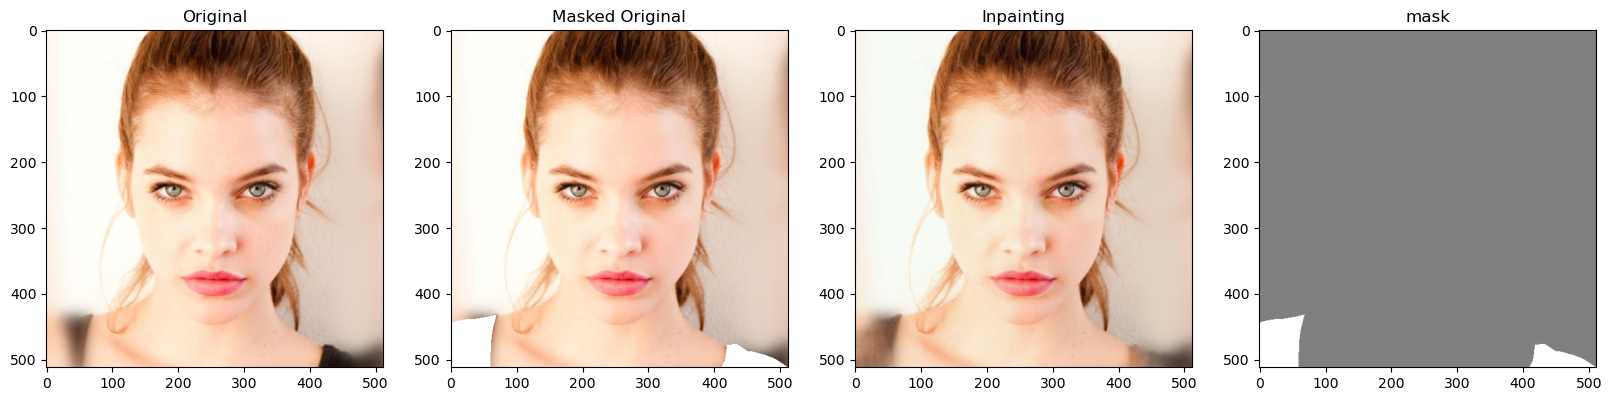

<Figure size 640x480 with 0 Axes>

2320.jpg


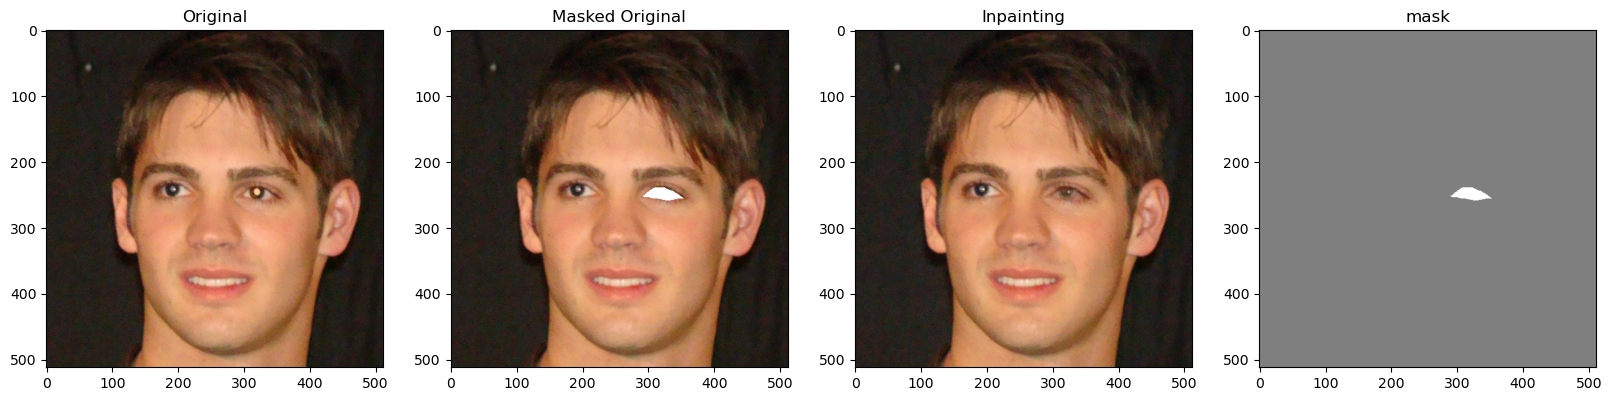

<Figure size 640x480 with 0 Axes>

2787.jpg


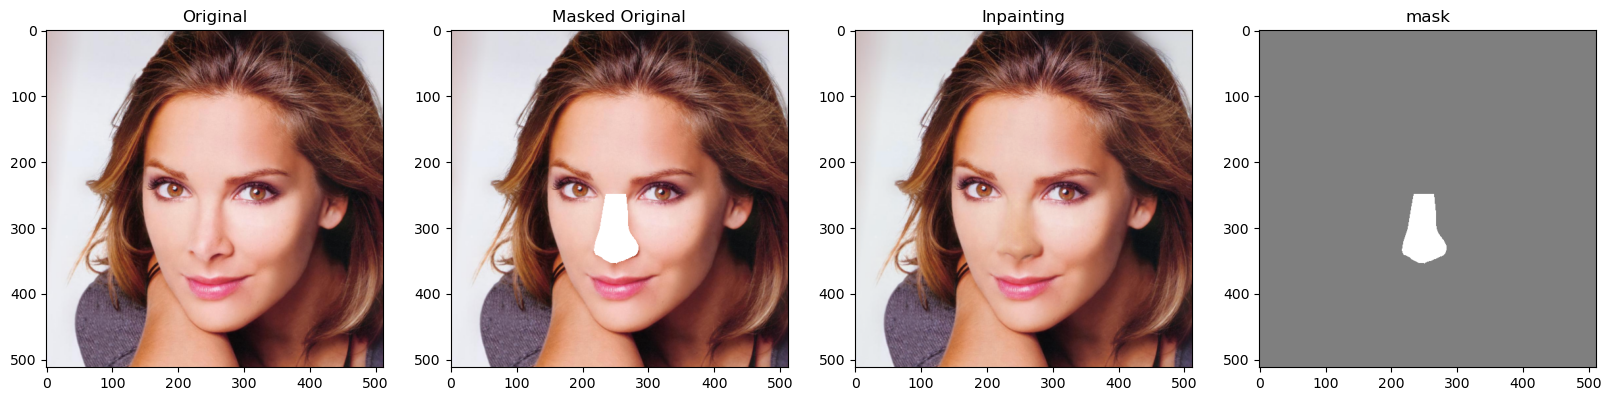

<Figure size 640x480 with 0 Axes>

3671.jpg


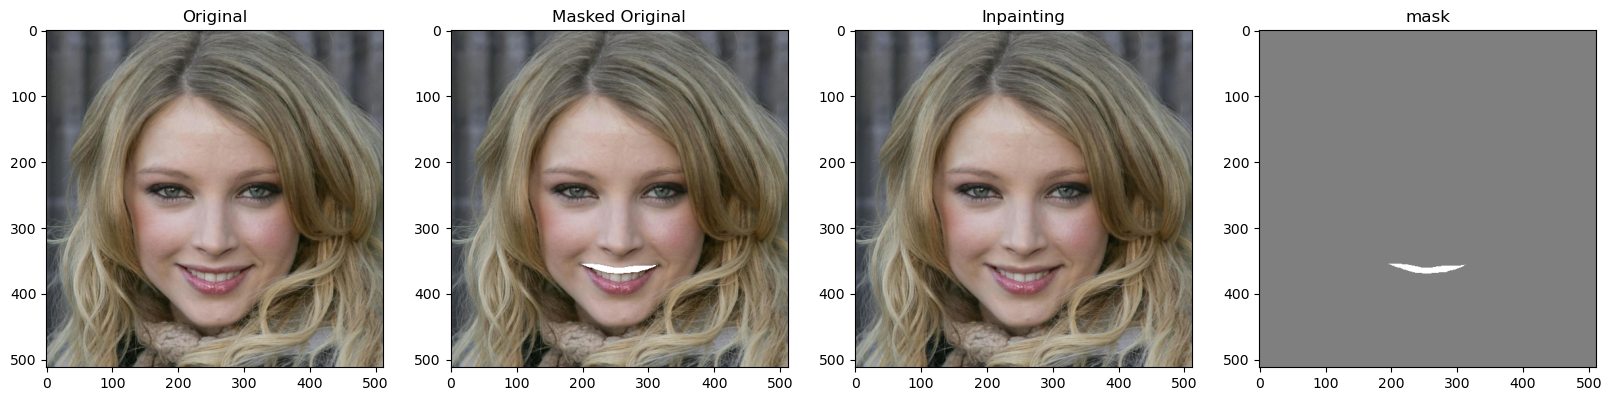

<Figure size 640x480 with 0 Axes>

In [6]:
from test.showimg import showimg
showimg()
showimg()
showimg()
showimg()

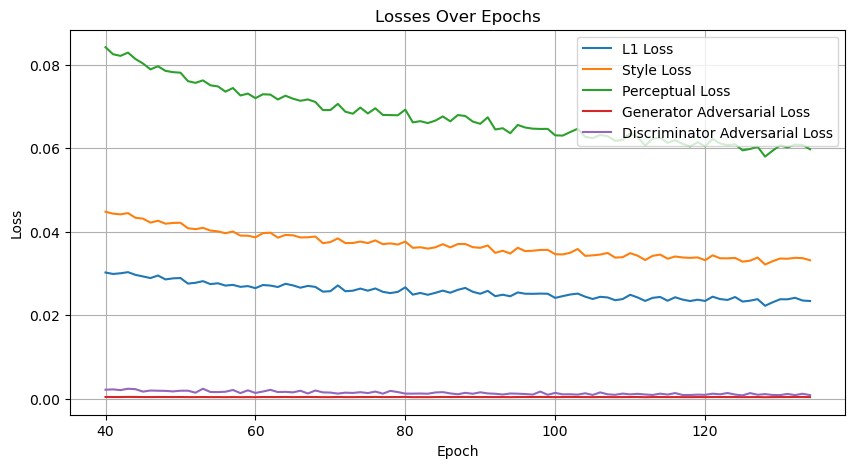

In [1]:
from test.printloss import printloss
printloss()

In [ ]:
## 更多实验结果已保存在output目录下